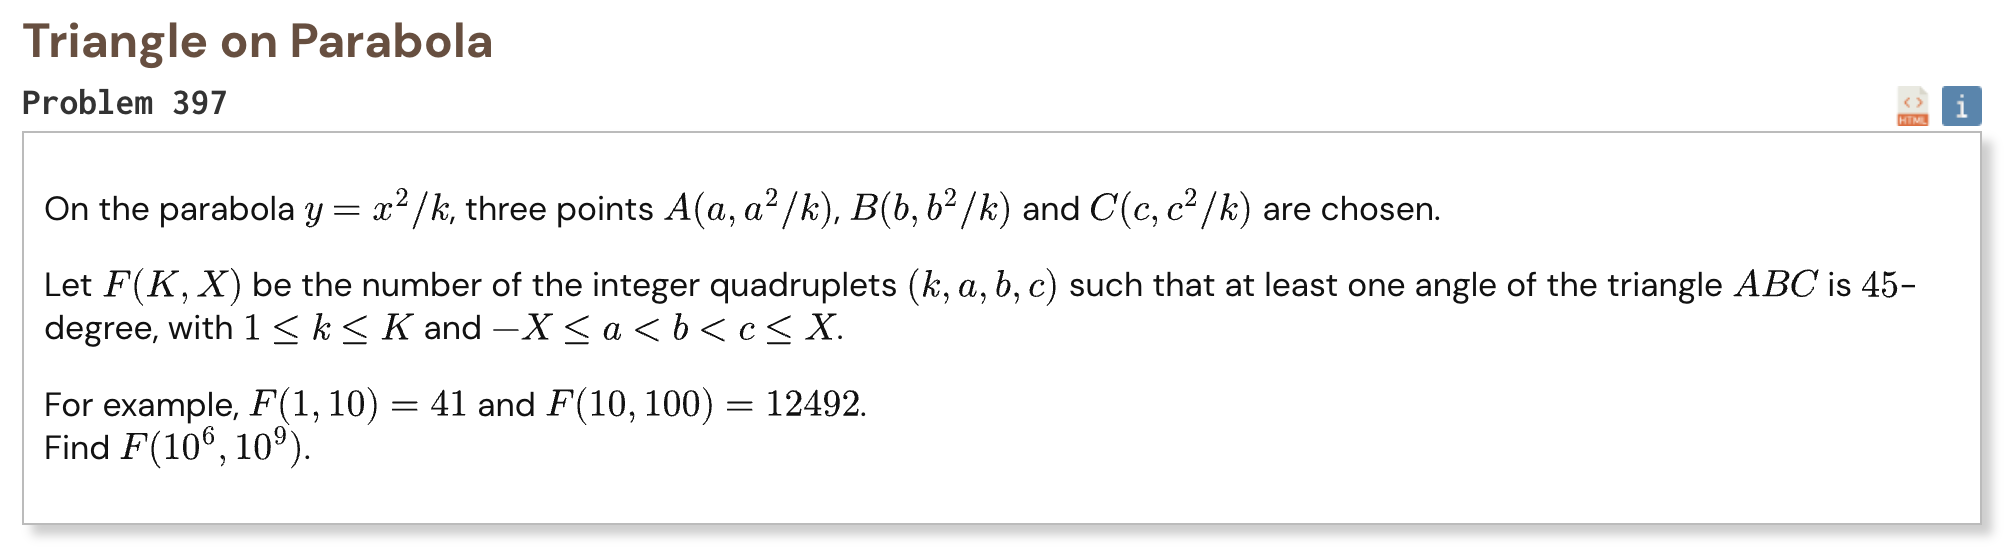

## Initial approach

-   the slope between two parabola points depends only on the sum of their x coordinates
-   express the 45 degree condition using the tangent formula between two slopes
-   after rearranging the equation becomes a factorization of two integers
-   these two factors multiply to two times k squared
-   generate every divisor of this value to obtain all possible coordinate sums
-   count valid ordered coordinates directly from their lower and upper bounds
-   count the cases for angles at A and B while using symmetry for angle C
-   subtract triangles counted twice because they contain two 45 degree angles

In [1]:
def smallest_prime_factors(limit):
    spf = list(range(limit + 1))

    for value in range(2, int(limit ** 0.5) + 1):
        if spf[value] == value:
            for multiple in range(value * value, limit + 1, value):
                if spf[multiple] == multiple:
                    spf[multiple] = value

    return spf


def divisors_of_two_k_squared(k, spf):
    factors = []
    value = k
    contains_two = False

    while value > 1:
        prime = spf[value]
        exponent = 0

        while value % prime == 0:
            value //= prime
            exponent += 1

        if prime == 2:
            factors.append((2, 2 * exponent + 1))
            contains_two = True
        else:
            factors.append((prime, 2 * exponent))

    if not contains_two:
        factors.append((2, 1))

    divisors = [1]

    for prime, exponent in factors:
        new_divisors = []
        power = 1

        for _ in range(exponent + 1):
            for divisor in divisors:
                new_divisors.append(divisor * power)

            power *= prime

        divisors = new_divisors

    return divisors


def count_left_angle(x, s, t):
    lower = max(-x, t - x)
    upper = min(x, s + x, (s - 1) // 2)

    return max(0, upper - lower + 1)


def count_middle_angle(x, p, q):
    lower = max(
        -x,
        p - x,
        q - x,
        p // 2 + 1
    )

    upper = min(
        x,
        p + x,
        (q - 1) // 2
    )

    return max(0, upper - lower + 1)


def solve(k_limit, x_limit):
    spf = smallest_prime_factors(k_limit)
    twice_x = 2 * x_limit

    left_angles = 0
    middle_angles = 0
    overlap_left_middle = 0
    overlap_left_right = 0

    for k in range(1, k_limit + 1):
        product = 2 * k * k
        divisors = divisors_of_two_k_squared(k, spf)

        for divisor in divisors:
            paired = product // divisor

            s = k - paired
            t = divisor - k

            if -twice_x <= s <= twice_x and -twice_x <= t <= twice_x:
                left_angles += count_left_angle(
                    x_limit,
                    s,
                    t
                )

                denominator = s + k

                if denominator != 0:
                    numerator = k * (s - k)

                    if numerator % denominator == 0:
                        q = numerator // denominator

                        if (
                            -twice_x <= q <= twice_x
                            and (s + t - q) % 2 == 0
                        ):
                            a = (s + t - q) // 2
                            b = (s + q - t) // 2
                            c = (t + q - s) // 2

                            if -x_limit <= a < b < c <= x_limit:
                                overlap_left_middle += 1

                denominator = k - t

                if denominator != 0:
                    numerator = k * (k + t)

                    if numerator % denominator == 0:
                        q = numerator // denominator

                        if (
                            -twice_x <= q <= twice_x
                            and (s + t - q) % 2 == 0
                        ):
                            a = (s + t - q) // 2
                            b = (s + q - t) // 2
                            c = (t + q - s) // 2

                            if -x_limit <= a < b < c <= x_limit:
                                overlap_left_right += 1

            p = -(k + paired)
            q = k + divisor

            if -twice_x <= p <= twice_x and q <= twice_x:
                middle_angles += count_middle_angle(
                    x_limit,
                    p,
                    q
                )

    result = (
        2 * left_angles
        + middle_angles
        - 2 * overlap_left_middle
        - overlap_left_right
    )

    return result

In [2]:
%%time
assert solve(1, 10) == 41
assert solve(10, 100) == 12492
result = solve(10 ** 6, 10 ** 9)
print("Result:", result)

Result: 141630459461893728
CPU times: user 2min 42s, sys: 1.24 s, total: 2min 43s
Wall time: 2min 45s
